In [1]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from typing import Union
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
from itertools import product
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
from tensorflow.keras import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.layers import Dense, Conv1D, LSTM, Lambda, Reshape, RNN, LSTMCell
from sklearn.preprocessing import MinMaxScaler




EP    0
dtype: int64


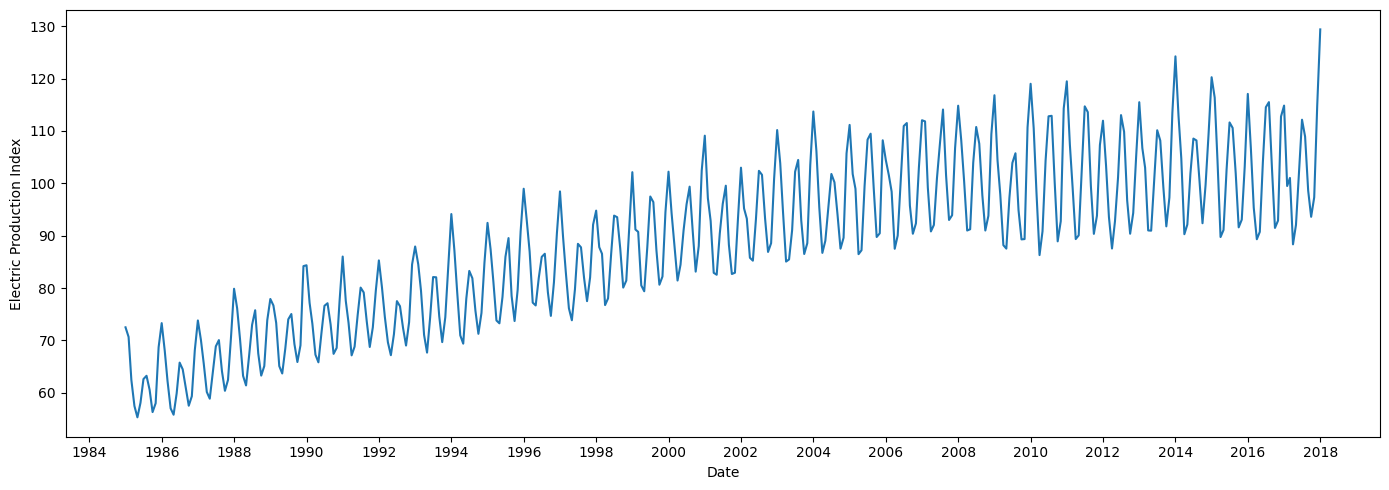

In [2]:
df = pd.read_csv('Electric_Production.csv')

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.set_index('DATE')
df = df.asfreq('MS')

# optional safety check
print(df.isna().sum())

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['EP'])

# ax.set_title('Monthly Electric Production Index in the USA')
ax.set_xlabel('Date')
ax.set_ylabel('Electric Production Index')

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('time_series.png', dpi=300, bbox_inches='tight')
plt.show()


In [3]:
# The series shows a clear upward trend and strong annual seasonality.
# Therefore, the raw series is likely non-stationary.
# Since the observations are monthly, the seasonal period is s = 12.
# A seasonal naive model is used as a baseline, while SARIMA is appropriate
# because it can handle both non-seasonal and seasonal differencing.

MAE: 4.1883375
RMSE: 6.224071020943608
MAPE: 3.9222087528583423


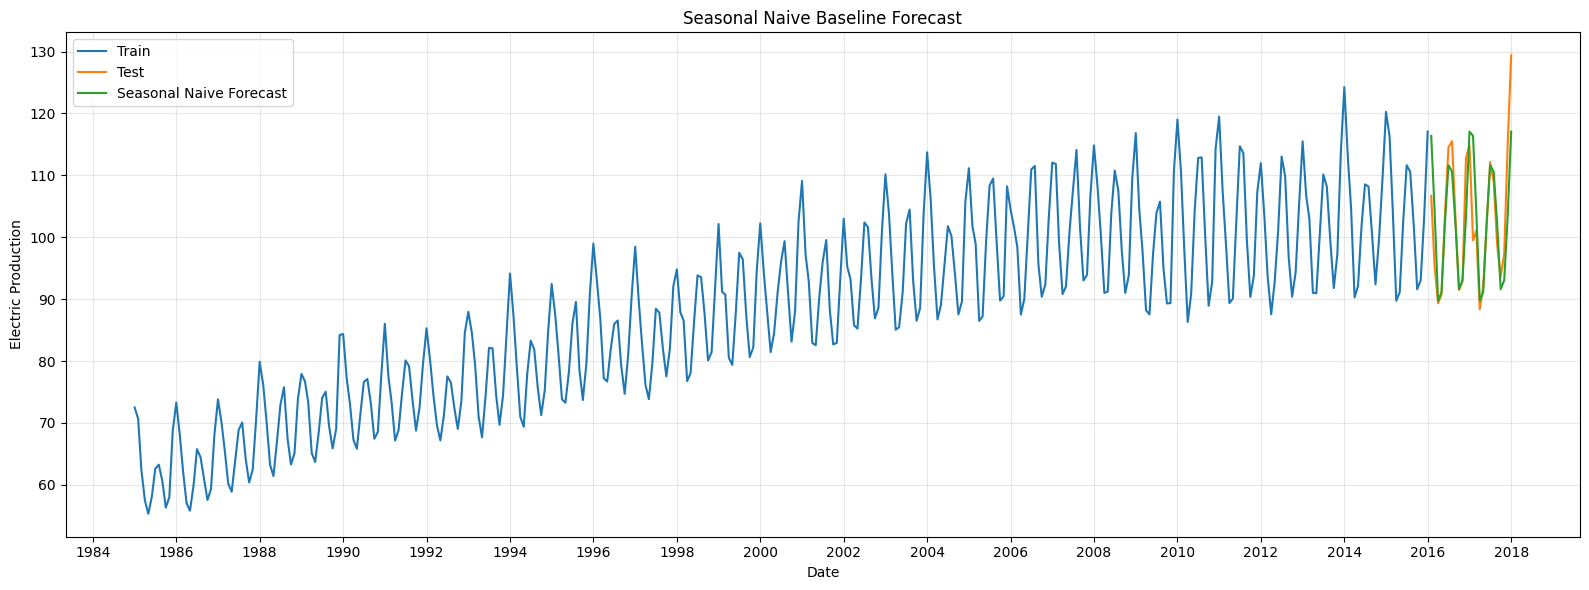

In [4]:
# seasonal naive model

# 2 years
test_size = 24
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

m = 12

def predict_seasonal_naive(train_data, horizon, m=12):
    last_season = train_data['EP'].iloc[-m:].values
    repetitions = int(np.ceil(horizon / m))
    forecast = np.tile(last_season, repetitions)[:horizon]
    return forecast

seasonal_naive_pred = predict_seasonal_naive(train, horizon=len(test), m=m)

mae_naive = mean_absolute_error(test['EP'], seasonal_naive_pred)
rmse_naive = np.sqrt(mean_squared_error(test['EP'], seasonal_naive_pred))
mape_naive = np.mean(np.abs((test['EP'].values - seasonal_naive_pred) / test['EP'].values)) * 100

print("MAE:", mae_naive)
print("RMSE:", rmse_naive)
print("MAPE:", mape_naive)

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(train.index, train['EP'], label='Train')
ax.plot(test.index, test['EP'], label='Test')
ax.plot(test.index, seasonal_naive_pred, label='Seasonal Naive Forecast')

ax.set_title('Seasonal Naive Baseline Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Electric Production')
ax.legend()
ax.grid(alpha=0.3)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('naive_forecast.png')
plt.show()

In [5]:
# statistical modelling
ADF_result = adfuller(df['EP'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')




ADF Statistic: -2.256990350047245
p-value: 0.1862146911658677


In [6]:
# The ADF test fails to reject the null hypothesis of a unit root.
# Therefore, the original series is treated as non-stationary.

In [7]:
# d = 1
data_diff = np.diff(df['EP'], n=1)
ADF_result = adfuller(data_diff)

print(f'ADF Statistic 1st diff: {ADF_result[0]}')
print(f'p-value 1st diff: {ADF_result[1]}')

ADF Statistic 1st diff: -7.104890882267351
p-value 1st diff: 4.0777865655385053e-10


In [8]:
# d=1 is enough, so the data is stationary after d=1

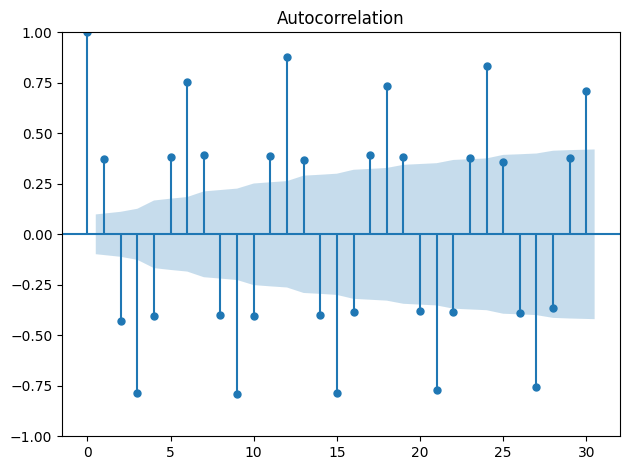

In [9]:
# autocorrelation
plot_acf(data_diff, lags=30);
plt.tight_layout()
plt.savefig("acf.png")
plt.show()



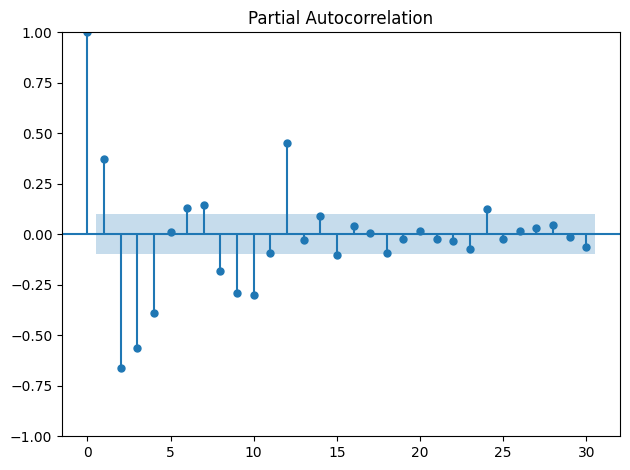

In [10]:
plot_pacf(data_diff, lags=30);
plt.tight_layout()
plt.savefig('pacf.png')
plt.show()

In [11]:
# there is seasonality in data, thus we need to use SARIMA model --> we have to estimate P; D; Q

In [12]:
data_seasonal_diff = np.diff(df['EP'], n=12)
ADF_seasonal_result = adfuller(data_seasonal_diff)

print(f'Seasonal ADF Statistic 1st diff: {ADF_seasonal_result[0]}')
print(f'Seasonal p-value 1st diff: {ADF_seasonal_result[1]}')



Seasonal ADF Statistic 1st diff: -28.045471475849133
Seasonal p-value 1st diff: 0.0


In [13]:
# D=1 is also enough

In [14]:
from itertools import product
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    # Initialize an empty list to store the results (parameter tuple and AIC score).
    results = []
    
    # Loop over each combination of parameters in the provided list.
    # order_list is expected to contain tuples of 4 values: (p, q, P, Q).
    for order in order_list:
        try: 
            # Initialize and fit the SARIMAX model.
            # endog: The time series data.
            # order=(p, d, q): 
            #   - order[0] is 'p' (AR order)
            #   - 'd' is the fixed trend integration order passed to the function
            #   - order[1] is 'q' (MA order)
            # seasonal_order=(P, D, Q, s):
            #   - order[2] is 'P' (Seasonal AR order)
            #   - 'D' is the fixed seasonal integration order
            #   - order[3] is 'Q' (Seasonal MA order)
            #   - 's' is the periodicity (m in the slides, e.g., 4 for quarterly, 12 for monthly)
            model = SARIMAX(
                endog, 
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False
            ).fit(disp=False) # disp=False prevents the model from printing convergence logs to the console.
            
        except:
            # If the model fails to converge (common with complex SARIMA grids), 
            # skip this iteration and move to the next combination.
            continue
            
        # Extract the Akaike Information Criterion (AIC).
        # This metric estimates the relative quality of statistical models for a given dataset.
        aic = model.aic
        
        # Append the current parameter tuple (p, q, P, Q) and its AIC to the results list.
        results.append([order, aic])
        
    # Convert the results list into a Pandas DataFrame for analysis.
    result_df = pd.DataFrame(results)
    
    # Name the columns. 'order' here represents the tuple (p, q, P, Q).
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    # Sort the dataframe by AIC in ascending order.
    # The slides  emphasize using AIC to select the "best" model,
    # where a lower AIC indicates a better model.
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    # Return the sorted dataframe so the best parameters are at the top (index 0).
    return result_df


ps = range(0, 4, 1)
qs = range(0, 4, 1)
Ps = range(0, 4, 1)
Qs = range(0, 4, 1)

SARIMA_order_list = list(product(ps, qs, Ps, Qs))

d = 1
D = 1
s = 12

SARIMA_result_df = optimize_SARIMA(train, SARIMA_order_list, d, D, s)
SARIMA_result_df




/Users/daniilsuba/Desktop/Queen Mary/Forecasting with AI/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/daniilsuba/Desktop/Queen Mary/Forecasting with AI/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/daniilsuba/Desktop/Queen Mary/Forecasting with AI/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/daniilsuba/Desktop/Queen Mary/Forecasting with AI/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed 

,"(p,q,P,Q)",AIC
0,"(2, 3, 1, 3)",1622.518981
1,"(2, 3, 0, 3)",1622.519626
2,"(3, 3, 0, 3)",1623.099861
3,"(2, 3, 2, 1)",1623.195516
4,"(2, 3, 2, 2)",1623.374249
...,...,...
251,"(2, 0, 0, 0)",1779.863829
252,"(3, 0, 0, 0)",1781.163409
253,"(0, 1, 0, 0)",1796.827905
254,"(1, 0, 0, 0)",1814.519044


In [15]:
# p = 2; q = 3; d = 1; P=1; D=1; Q=3; s=12 is the best model 
# (2, 3, 1, 3) with 1622.519 AIC (smallest aic)

In [16]:
model_sarima = SARIMAX(
    train, 
    order=(2, 1, 3),
    seasonal_order=(1, 1, 3, 12),
    simple_differencing=False
)
model_fit_sarima = model_sarima.fit(disp=False)

print(model_fit_sarima.summary())



                                     SARIMAX Results                                      
Dep. Variable:                                 EP   No. Observations:                  373
Model:             SARIMAX(2, 1, 3)x(1, 1, 3, 12)   Log Likelihood                -801.259
Date:                            Thu, 30 Apr 2026   AIC                           1622.519
Time:                                    13:13:18   BIC                           1661.380
Sample:                                01-01-1985   HQIC                          1637.971
                                     - 01-01-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6918      0.108     -6.425      0.000      -0.903      -0.481
ar.L2          0.2835      0.103   

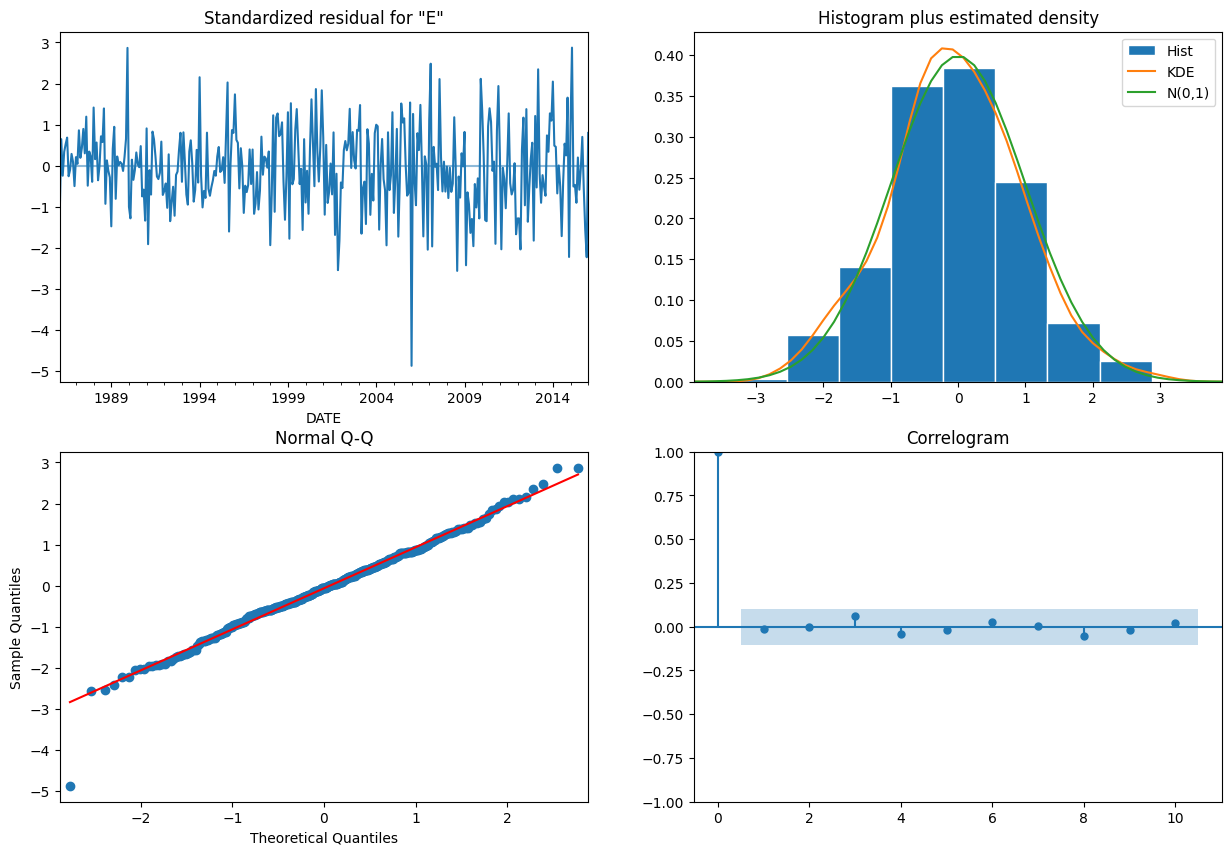

In [17]:
model_fit_sarima.plot_diagnostics(figsize=(15,10))
plt.savefig('model_fit_sarima.png')
plt.show()


residuals = model_fit_sarima.resid
df_results = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1), return_df=True)






In [18]:
print(df_results)

     lb_stat  lb_pvalue
1   0.442776   0.505786
2   3.943020   0.139246
3   4.101770   0.250682
4   4.315469   0.364992
5   4.496316   0.480377
6   4.868861   0.560740
7   4.869806   0.675848
8   5.317551   0.723159
9   5.830966   0.756710
10  6.861058   0.738494


In [19]:
forecast_obj = model_fit_sarima.get_forecast(steps=len(test))
forecast_values = forecast_obj.predicted_mean

mae_sarima = mean_absolute_error(test['EP'], forecast_values)
rmse_sarima = np.sqrt(mean_squared_error(test['EP'], forecast_values))
mape_sarima = np.mean(np.abs((test['EP'].values - forecast_values) / test['EP'].values)) * 100

print("MAE SARIMA:", mae_sarima)
print("RMSE SARIMA:", rmse_sarima)
print("MAPE SARIMA:", mape_sarima)





MAE SARIMA: 2.716428243167058
RMSE SARIMA: 3.777258413276431
MAPE SARIMA: 2.549307868348706


In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

test_size = 24

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# Additive ETS
ets_add = ExponentialSmoothing(
    train['EP'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

forecast_add = ets_add.forecast(test_size)
mae_add, rmse_add, mape_add = evaluate_forecast(test['EP'], forecast_add)

# Multiplicative ETS
ets_mul = ExponentialSmoothing(
    train['EP'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()

forecast_mul = ets_mul.forecast(test_size)
mae_mul, rmse_mul, mape_mul = evaluate_forecast(test['EP'], forecast_mul)

print("ETS additive:")
print("MAE:", mae_add)
print("RMSE:", rmse_add)
print("MAPE:", mape_add)

print("\nETS multiplicative:")
print("MAE:", mae_mul)
print("RMSE:", rmse_mul)
print("MAPE:", mape_mul)

ETS additive:
MAE: 3.266477709657884
RMSE: 4.22756741314259
MAPE: 3.0646446103169387

ETS multiplicative:
MAE: 3.123345907462482
RMSE: 4.262079493027858
MAPE: 2.9054584744543592


In [21]:
# train LSTM
test_size = 24
val_size = 24

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

train_lstm = train.iloc[:-val_size]
val_lstm = train.iloc[-val_size:]

scaler = MinMaxScaler()

scaler.fit(train_lstm[['EP']])

train_scaled = scaler.transform(train_lstm[['EP']])
val_scaled = scaler.transform(val_lstm[['EP']])
test_scaled = scaler.transform(test[['EP']])


def make_windows(data, input_width=24, label_width=24, shift=24):
    X, y = [], []
    total_window_size = input_width + shift

    for i in range(len(data) - total_window_size + 1):
        X.append(data[i:i+input_width])
        y.append(data[i+total_window_size-label_width:i+total_window_size])

    return np.array(X), np.array(y)

input_width = 24
label_width = 24
shift = 24

X_train, y_train = make_windows(
    train_scaled,
    input_width=input_width,
    label_width=label_width,
    shift=shift
)

# validation needs previous context
val_input = np.vstack([train_scaled[-input_width:], val_scaled])

X_val, y_val = make_windows(
    val_input,
    input_width=input_width,
    label_width=label_width,
    shift=shift
)

# test needs previous context from full train
train_scaled_full = scaler.transform(train[['EP']])
test_input = np.vstack([train_scaled_full[-input_width:], test_scaled])

X_test, y_test = make_windows(
    test_input,
    input_width=input_width,
    label_width=label_width,
    shift=shift
)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)








(302, 24, 1) (302, 24, 1)
(1, 24, 1) (1, 24, 1)
(1, 24, 1) (1, 24, 1)


In [22]:
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(input_width, 1)),
    Dense(label_width),
    Reshape((label_width, 1))
])

lstm_model.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=0.001),
    metrics=[MeanAbsoluteError()]
)

lstm_model.summary()

/Users/daniilsuba/Desktop/Queen Mary/Forecasting with AI/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,456 (72.09 KB)

 Trainable params: 18,456 (72.09 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1926 - mean_absolute_error: 0.3827 - val_loss: 0.1619 - val_mean_absolute_error: 0.3236
Epoch 2/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0315 - mean_absolute_error: 0.1365 - val_loss: 0.0179 - val_mean_absolute_error: 0.1125
Epoch 3/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0149 - mean_absolute_error: 0.1012 - val_loss: 0.0165 - val_mean_absolute_error: 0.1074
Epoch 4/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0129 - mean_absolute_error: 0.0956 - val_loss: 0.0202 - val_mean_absolute_error: 0.1194
Epoch 5/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127 - mean_absolute_error: 0.0949 - val_loss: 0.0175 - val_mean_absolute_error: 0.1125
Epoch 6/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127 - mean_absolute_error: 0.0951 - val_loss: 0.0189 - val_mean_absolute_error: 0.1164
Epoch 7/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127 - mean_absolute_error: 0.0950 - val_los

In [24]:
lstm_pred_scaled = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled.reshape(-1, 1)
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


In [25]:
mae_lstm = mean_absolute_error(y_test_actual, lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
mape_lstm = np.mean(np.abs((y_test_actual - lstm_pred) / y_test_actual)) * 100

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)
print("LSTM MAPE:", mape_lstm)

LSTM MAE: 4.027892643229166
LSTM RMSE: 5.432831794039739
LSTM MAPE: 3.812196227524135


In [26]:
# to make sure model is not overfitted

val_pred_scaled = lstm_model.predict(X_val)

val_pred = scaler.inverse_transform(val_pred_scaled.reshape(-1, 1))
y_val_actual = scaler.inverse_transform(y_val.reshape(-1, 1))

mae_val_lstm = mean_absolute_error(y_val_actual, val_pred)
rmse_val_lstm = np.sqrt(mean_squared_error(y_val_actual, val_pred))
mape_val_lstm = np.mean(np.abs((y_val_actual - val_pred) / y_val_actual)) * 100

print("LSTM Validation MAE:", mae_val_lstm)
print("LSTM Validation RMSE:", rmse_val_lstm)
print("LSTM Validation MAPE:", mape_val_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
LSTM Validation MAE: 2.37971604156494
LSTM Validation RMSE: 3.1434356864956885
LSTM Validation MAPE: 2.2875250640851053


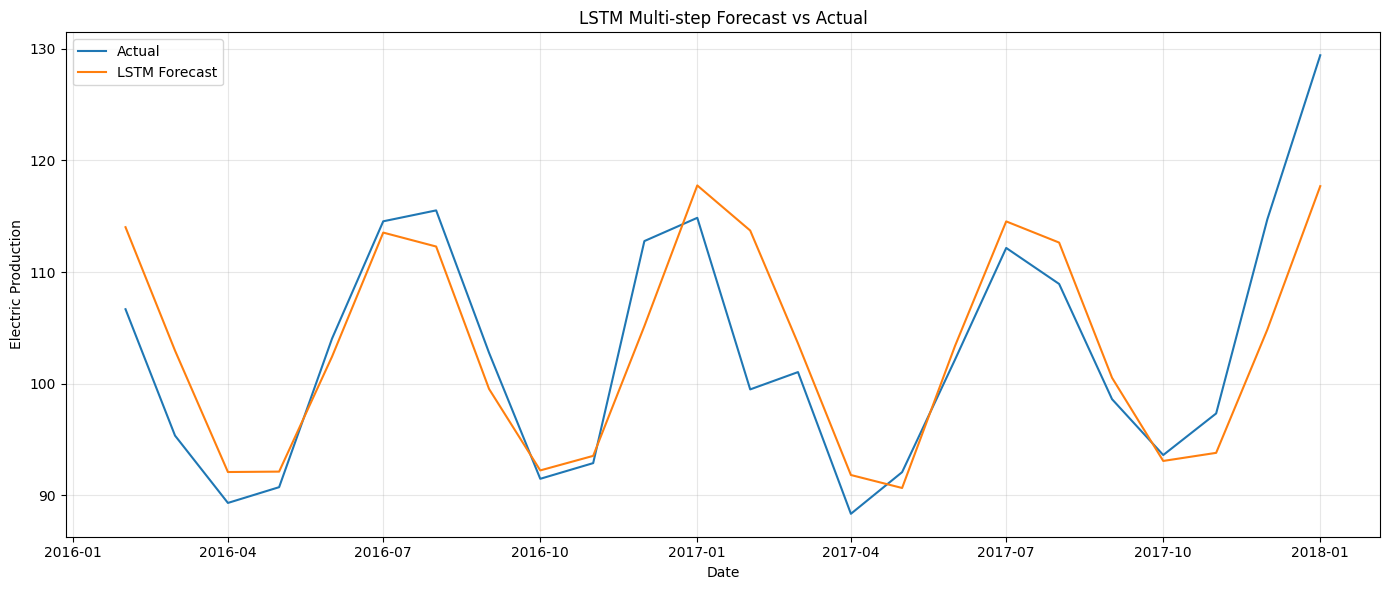

In [27]:
plt.figure(figsize=(14, 6))

plt.plot(test.index, y_test_actual, label='Actual')
plt.plot(test.index, lstm_pred, label='LSTM Forecast')

plt.title('LSTM Multi-step Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Electric Production')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

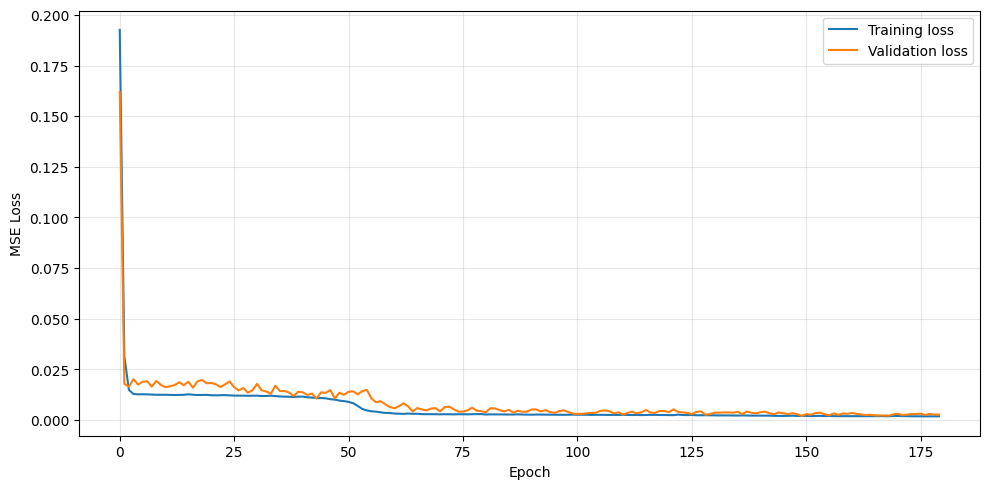

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')

# plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_loss.png')
plt.show()

/var/folders/r_/c9n7lbds7lngpw1ghzd_ykdw0000gn/T/ipykernel_79978/3939136644.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(metrics_df['Model'], rotation=30, ha='right')
/var/folders/r_/c9n7lbds7lngpw1ghzd_ykdw0000gn/T/ipykernel_79978/3939136644.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(metrics_df['Model'], rotation=30, ha='right')
/var/folders/r_/c9n7lbds7lngpw1ghzd_ykdw0000gn/T/ipykernel_79978/3939136644.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(metrics_df['Model'], rotation=30, ha='right')


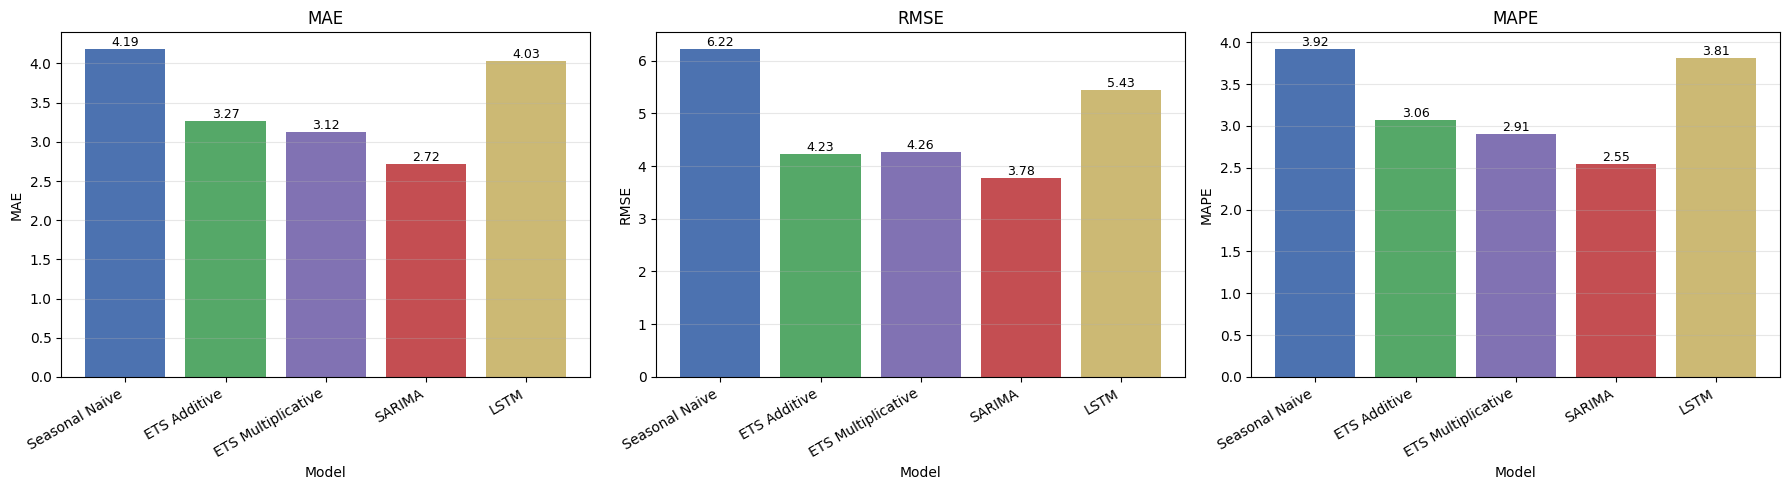

In [29]:
metrics_df = pd.DataFrame({
    'Model': [
        'Seasonal Naive',
        'ETS Additive',
        'ETS Multiplicative',
        'SARIMA',
        'LSTM'
    ],
    'MAE': [
        mae_naive,
        mae_add,
        mae_mul,
        mae_sarima,
        mae_lstm
    ],
    'RMSE': [
        rmse_naive,
        rmse_add,
        rmse_mul,
        rmse_sarima,
        rmse_lstm
    ],
    'MAPE': [
        mape_naive,
        mape_add,
        mape_mul,
        mape_sarima,
        mape_lstm
    ]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['MAE', 'RMSE', 'MAPE']
colors = ['#4C72B0', '#55A868', '#8172B3', '#C44E52', '#CCB974']

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    values = metrics_df[metric]
    bars = ax.bar(metrics_df['Model'], values, color=colors)
    
    ax.set_title(metric, fontsize=12)
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    
    ax.set_xticklabels(metrics_df['Model'], rotation=30, ha='right')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )
    
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# rolling window for the best model


def rolling_sarima(
    endog: Union[pd.Series, list],
    train_len: int,
    horizon: int,
    window: int,
    order: tuple,
    seasonal_order: tuple
) -> list:
    
    total_len = train_len + window
    predictions = []

    for i in range(train_len, total_len, horizon):
        
        model = SARIMAX(
            endog[:i],
            order=order,
            seasonal_order=seasonal_order,
            simple_differencing=False,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        model_fit = model.fit(disp=False)
        
        forecast = model_fit.get_forecast(steps=horizon)
        preds = forecast.predicted_mean
        
        predictions.extend(preds.values)

    return predictions[:window]


order = (2, 1, 3)
seasonal_order = (1, 1, 3, 12)

rolling_preds = rolling_sarima(
    endog=df['EP'],
    train_len=len(train),
    horizon=1,
    window=len(test),
    order=order,
    seasonal_order=seasonal_order
)

y_true = np.asarray(test).reshape(-1)
y_pred = np.asarray(rolling_preds).reshape(-1)
mae_rolling_sarima = mean_absolute_error(y_true, rolling_preds)
rmse_rolling_sarima = np.sqrt(mean_squared_error(y_true, rolling_preds))
mape_rolling_sarima = np.mean(np.abs((y_true - rolling_preds) / y_true)) * 100

print(f"Rolling sarima mae: {mae_rolling_sarima}")
print(f"Rolling sarima rmse: {rmse_rolling_sarima}")
print(f"Rolling sarima mape: {mape_rolling_sarima}")



/Users/daniilsuba/Desktop/Queen Mary/Forecasting with AI/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/daniilsuba/Desktop/Queen Mary/Forecasting with AI/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/daniilsuba/Desktop/Queen Mary/Forecasting with AI/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/daniilsuba/Desktop/Queen Mary/Forecasting with AI/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed 

Rolling sarima mae: 3.0242819770030613
Rolling sarima rmse: 3.782897640363077
Rolling sarima mape: 2.8944848876659113


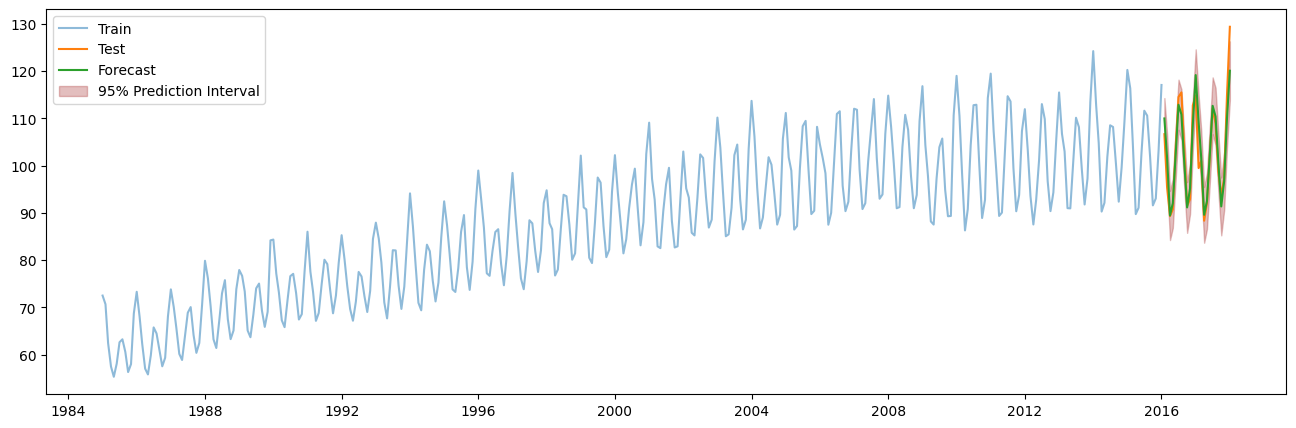

In [31]:
forecast = model_fit_sarima.get_forecast(steps=len(test))

mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

lower = conf_int.iloc[:, 0]
upper = conf_int.iloc[:, 1]

plt.figure(figsize=(16,5))

plt.plot(train.index, train, label='Train', alpha=0.5)
plt.plot(test.index, test, label='Test')
plt.plot(test.index, mean_forecast, label='Forecast')

plt.fill_between(
    test.index,
    lower,
    upper,
    color='brown',
    alpha=0.3,
    label='95% Prediction Interval'
)

plt.legend()
plt.savefig('sarima_prediction_interval.png')
plt.show()
